# 02 — Model Development

Train and evaluate TF-IDF + Random Forest baseline and Logistic Regression ensemble.

**Data:** Live API corpus (ArXiv, PubMed, Wikipedia) — 968 documents, 4 categories.

**Models:**
- Random Forest (300 estimators, balanced class weights)
- Logistic Regression (max_iter=1000, balanced class weights)
- Optional: DistilBERT fine-tuning (requires GPU + transformers)

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split

X = np.load('../data/processed/X_tfidf.npy')
y = np.load('../data/processed/y.npy')
vectorizer = joblib.load('../data/processed/tfidf_vectorizer.pkl')
le = joblib.load('../data/processed/label_encoder.pkl')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {len(X_train)} documents')
print(f'Test:  {len(X_test)} documents')
print(f'Features: {X.shape[1]}')
print(f'Classes: {le.classes_}')

Train: 774 documents
Test:  194 documents
Features: 5000
Classes: ['financial' 'legal' 'medical' 'scientific']


In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

rf = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_split=2,
    class_weight='balanced', n_jobs=-1, random_state=42
)
rf.fit(X_train, y_train)

lr = LogisticRegression(
    max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1
)
lr.fit(X_train, y_train)

rf_acc = rf.score(X_test, y_test)
lr_acc = lr.score(X_test, y_test)
print(f'Random Forest accuracy: {rf_acc:.4f}')
print(f'Logistic Regression accuracy: {lr_acc:.4f}')

Random Forest accuracy: 0.8608
Logistic Regression accuracy: 0.9124


In [3]:
from sklearn.model_selection import cross_val_score

rf_cv = cross_val_score(rf, X, y, cv=5, scoring='accuracy', n_jobs=-1)
lr_cv = cross_val_score(lr, X, y, cv=5, scoring='accuracy', n_jobs=-1)

print('Random Forest CV (5-fold):')
print(f'  Accuracy: {rf_cv.mean():.4f} (+/- {rf_cv.std()*2:.4f})')
print(f'  Fold scores: {rf_cv.round(4)}')
print()
print('Logistic Regression CV (5-fold):')
print(f'  Accuracy: {lr_cv.mean():.4f} (+/- {lr_cv.std()*2:.4f})')
print(f'  Fold scores: {lr_cv.round(4)}')

Random Forest CV (5-fold):
  Accuracy: 0.8853 (+/- 0.0179)
  Fold scores: [0.8814 0.8918 0.8866 0.8964 0.8705]

Logistic Regression CV (5-fold):
  Accuracy: 0.9432 (+/- 0.0362)
  Fold scores: [0.9278 0.933  0.9278 0.9741 0.9534]


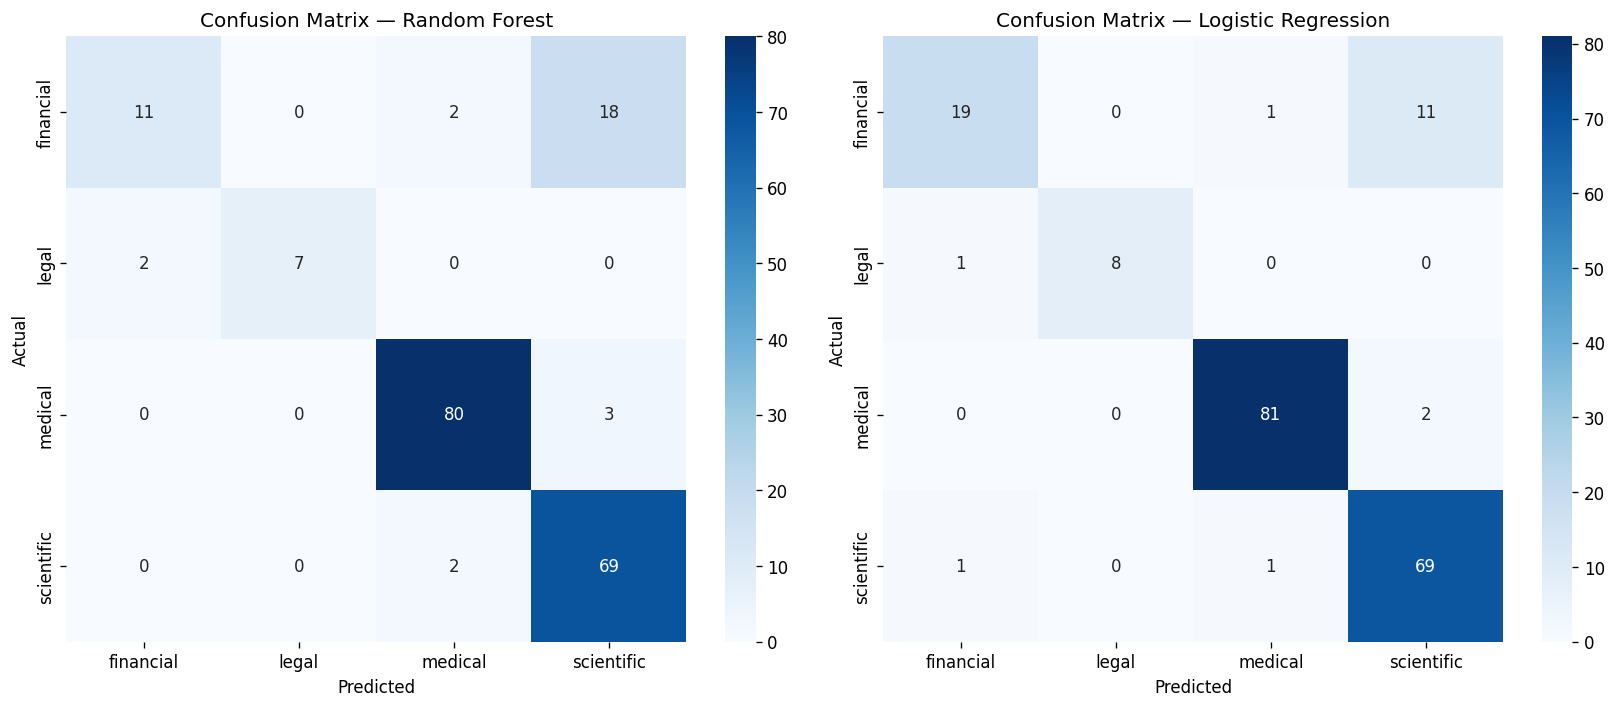

In [4]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, model, name in [(axes[0], rf, 'Random Forest'), (axes[1], lr, 'Logistic Regression')]:
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    ax.set_title(f'Confusion Matrix — {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

In [5]:
from sklearn.metrics import classification_report

y_pred_rf = rf.predict(X_test)
y_pred_lr = lr.predict(X_test)

print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))
print('=== Logistic Regression ===')
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

=== Random Forest ===
              precision    recall  f1-score   support

   financial       0.85      0.35      0.50        31
       legal       1.00      0.78      0.88         9
     medical       0.95      0.96      0.96        83
  scientific       0.77      0.97      0.86        71

    accuracy                           0.86       194
   macro avg       0.89      0.77      0.80       194
weighted avg       0.87      0.86      0.84       194

=== Logistic Regression ===
              precision    recall  f1-score   support

   financial       0.90      0.61      0.73        31
       legal       1.00      0.89      0.94         9
     medical       0.98      0.98      0.98        83
  scientific       0.84      0.97      0.90        71

    accuracy                           0.91       194
   macro avg       0.93      0.86      0.89       194
weighted avg       0.92      0.91      0.91       194



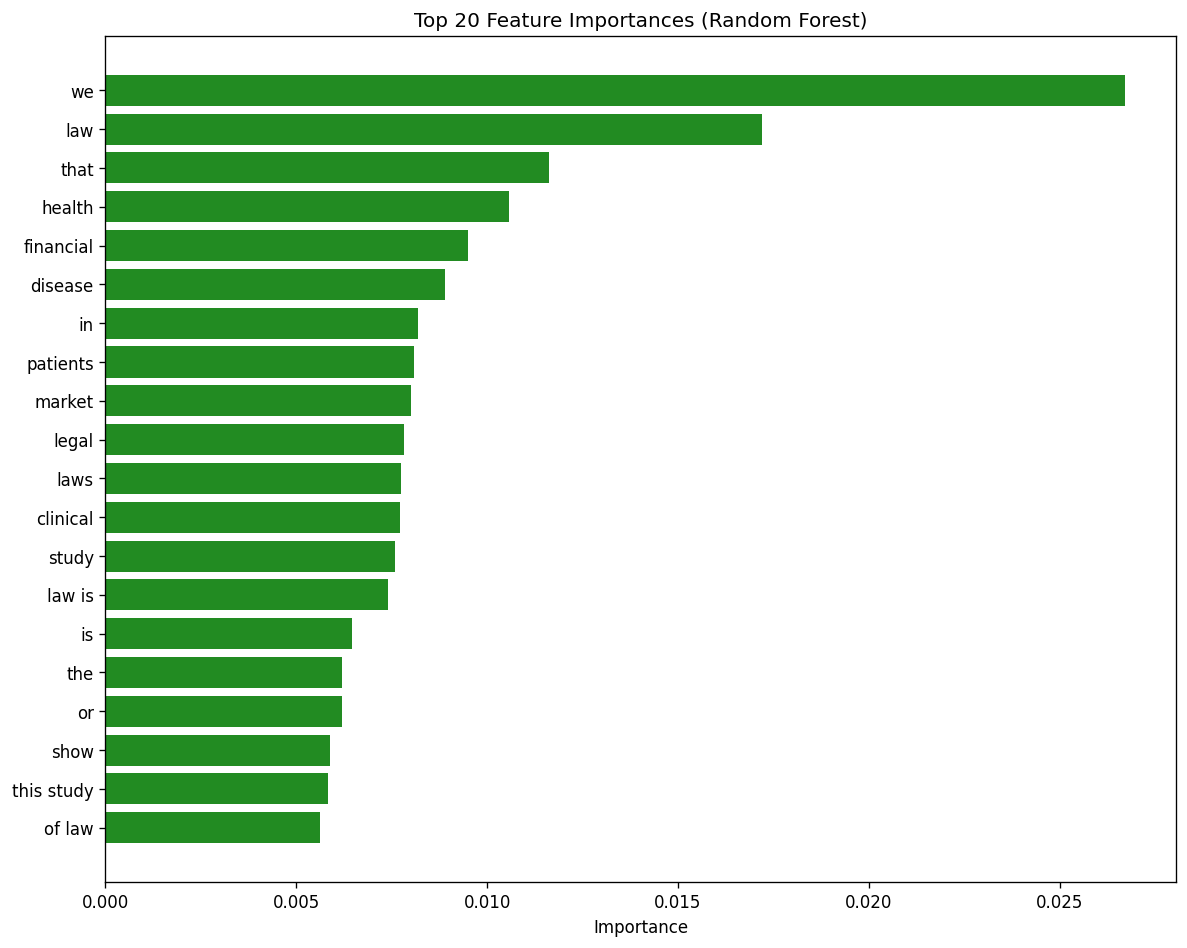

In [6]:
importances = rf.feature_importances_
top_idx = np.argsort(importances)[-20:][::-1]
top_features = [feature_names[i] for i in top_idx]
top_scores = importances[top_idx]

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(len(top_features))
ax.barh(y_pos, top_scores, color='forestgreen')
ax.set_yticks(y_pos)
ax.set_yticklabels(top_features)
ax.invert_yaxis()
ax.set_title('Top 20 Feature Importances (Random Forest)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

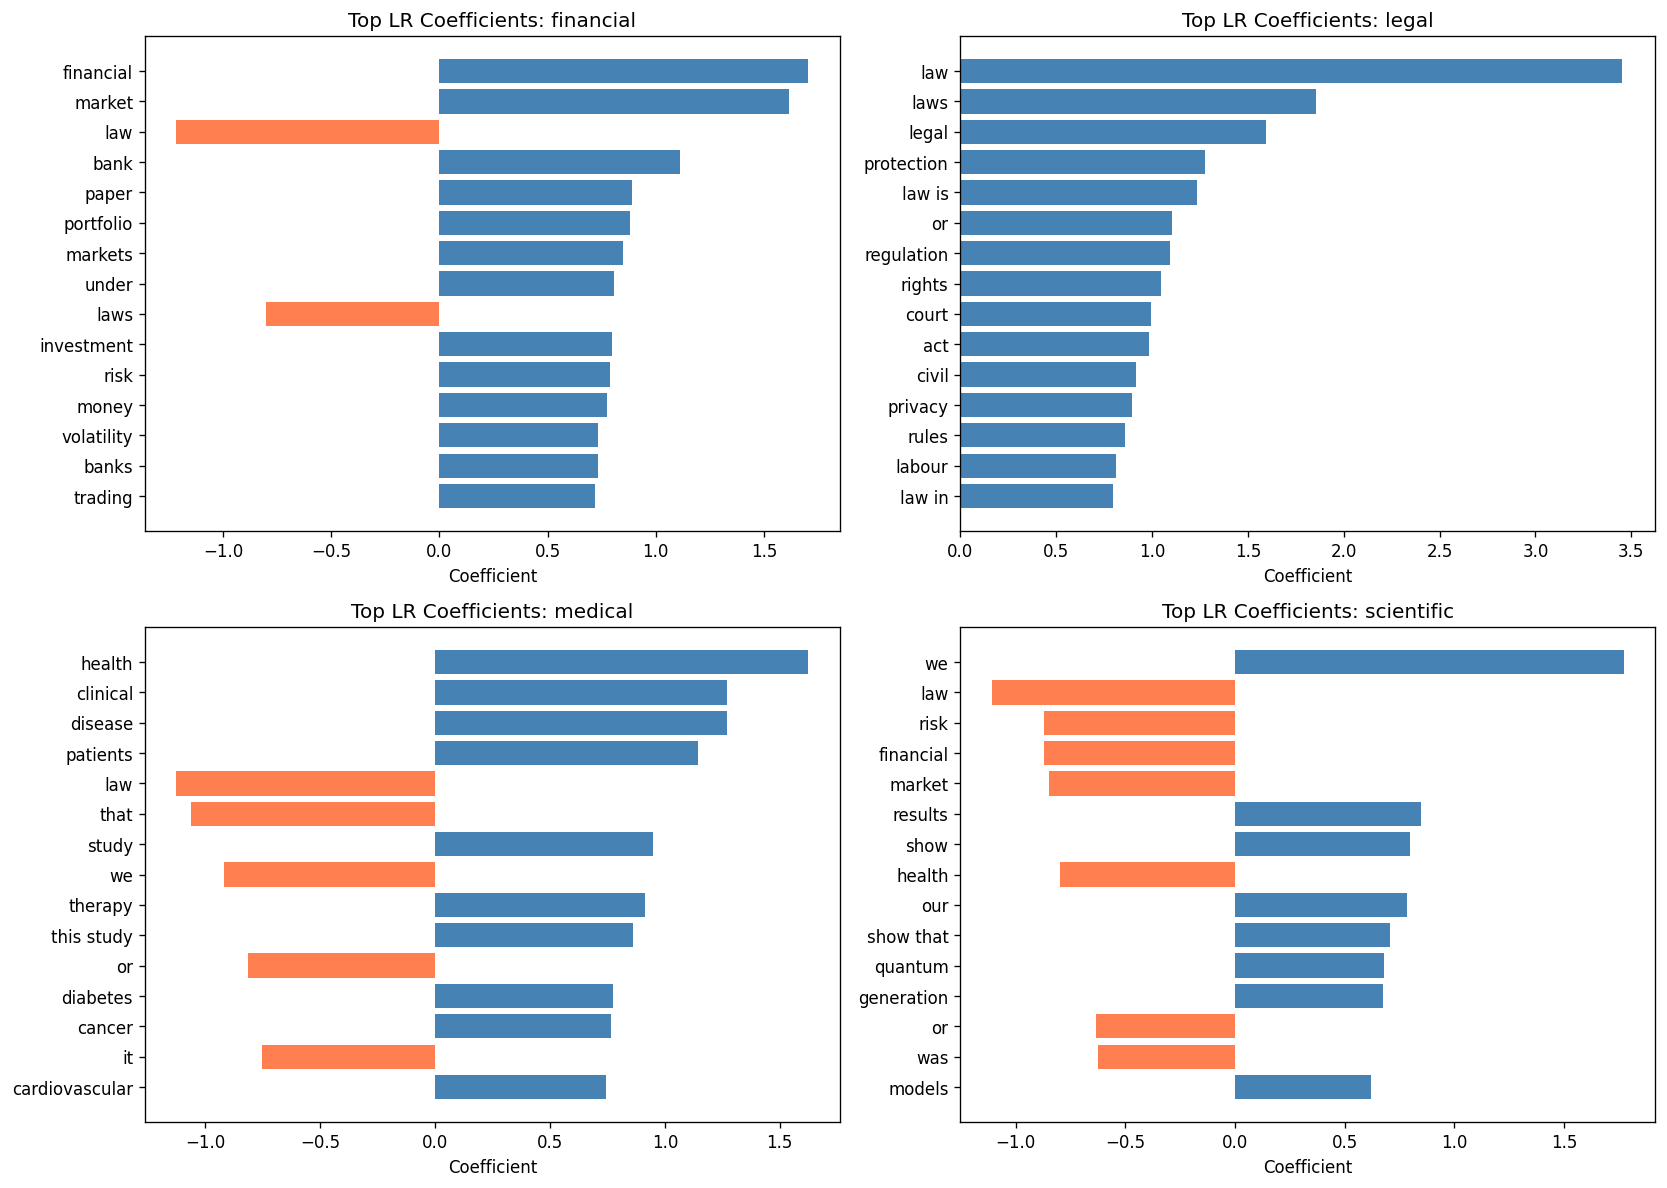

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, cls in enumerate(le.classes_):
    coef = lr.coef_[idx]
    top_idx = np.argsort(np.abs(coef))[-15:][::-1]
    top_feats = [feature_names[i] for i in top_idx]
    top_vals = coef[top_idx]
    ax = axes[idx]
    colors = ['steelblue' if v > 0 else 'coral' for v in top_vals]
    y_pos = np.arange(len(top_feats))
    ax.barh(y_pos, top_vals, color=colors)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_feats)
    ax.invert_yaxis()
    ax.set_title(f'Top LR Coefficients: {cls}')
    ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.show()

In [8]:
import numpy as np
from sklearn.model_selection import train_test_split

# Recover test indices using same split
_, test_idx = train_test_split(np.arange(len(X)), test_size=0.2, random_state=42, stratify=y)
test_df = df.iloc[test_idx].copy()
test_df['true_label'] = le.inverse_transform(y_test)
test_df['pred_label_rf'] = le.inverse_transform(y_pred_rf)
test_df['pred_label_lr'] = le.inverse_transform(y_pred_lr)

mis_rf = test_df[test_df['true_label'] != test_df['pred_label_rf']]
mis_lr = test_df[test_df['true_label'] != test_df['pred_label_lr']]

print(f'RF misclassifications: {len(mis_rf)} / {len(test_df)} ({len(mis_rf)/len(test_df):.1%})')
print(f'LR misclassifications: {len(mis_lr)} / {len(test_df)} ({len(mis_lr)/len(test_df):.1%})')
print()
print('Top confusion pairs (RF):')
print(mis_rf.groupby(['true_label', 'pred_label_rf']).size().reset_index(name='count').sort_values('count', ascending=False).head(8).to_string(index=False))
print()
print('Top confusion pairs (LR):')
print(mis_lr.groupby(['true_label', 'pred_label_lr']).size().reset_index(name='count').sort_values('count', ascending=False).head(8).to_string(index=False))

Random Forest misclassifications: 27 / 194 (13.9%)
Logistic Regression misclassifications: 17 / 194 (8.8%)

Top confusion pairs (RF):
true_label pred_label_rf  count
 financial    scientific     18
   medical    scientific      3
 financial       medical      2
     legal     financial      2
scientific       medical      2

Top confusion pairs (LR):
true_label pred_label_lr  count
 financial    scientific     11
   medical    scientific      2
 financial       medical      1
     legal     financial      1
scientific     financial      1
scientific       medical      1


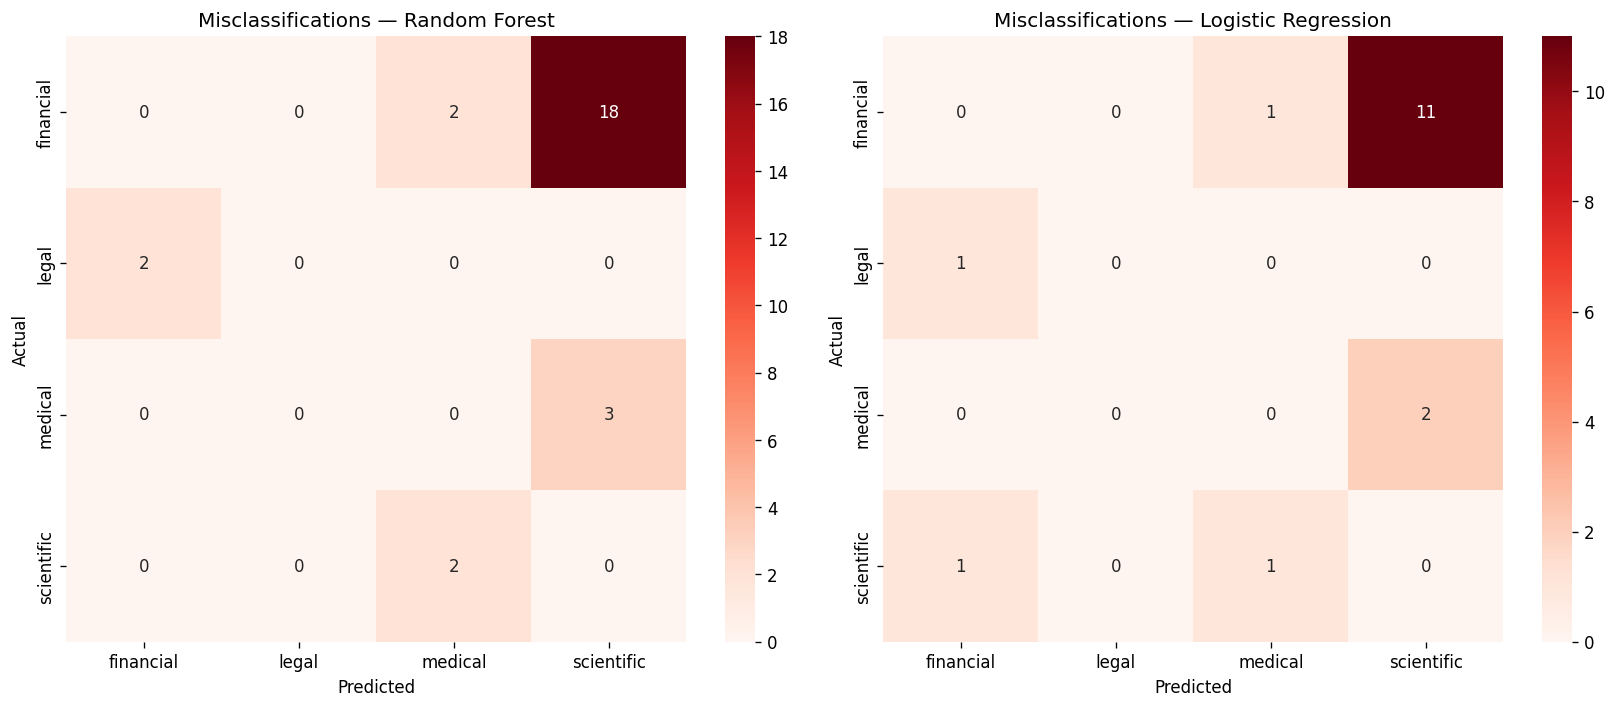

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, mis, pred_col, name in [
    (axes[0], mis_rf, 'pred_label_rf', 'Random Forest'),
    (axes[1], mis_lr, 'pred_label_lr', 'Logistic Regression')
]:
    if len(mis) > 0:
        cm = pd.crosstab(mis['true_label'], mis[pred_col])
        cm = cm.reindex(index=le.classes_, columns=le.classes_, fill_value=0)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax,
                    xticklabels=le.classes_, yticklabels=le.classes_)
        ax.set_title(f'Misclassifications — {name}')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
    else:
        ax.text(0.5, 0.5, 'No misclassifications', ha='center', va='center')
        ax.set_title(f'Misclassifications — {name}')
plt.tight_layout()
plt.show()

In [10]:
metrics = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression'],
    'Accuracy': [0.8608, 0.9124],
    'F1-macro': [0.7976, 0.8875],
    'F1-weighted': [0.8441, 0.9081],
    'CV-mean': [rf_cv.mean().round(4), lr_cv.mean().round(4)],
    'CV-std': [rf_cv.std().round(4), lr_cv.std().round(4)],
})
print(metrics.to_string(index=False))

              Model  Accuracy  F1-macro  F1-weighted  CV-mean  CV-std
      Random Forest    0.8608    0.7976       0.8441   0.8853  0.0090
Logistic Regression    0.9124    0.8875       0.9081   0.9432  0.0181


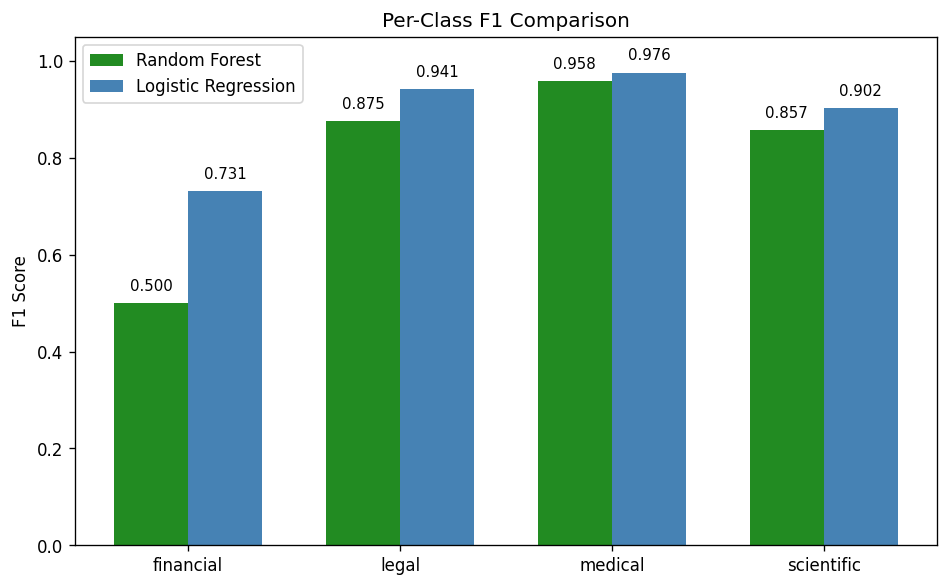

In [11]:
from sklearn.metrics import f1_score

per_class_f1 = pd.DataFrame({
    'Class': le.classes_,
    'RF F1': [f1_score(y_test, y_pred_rf, labels=[le.transform([c])[0] for c in le.classes_], average=None)[le.transform([c])[0]] for c in le.classes_],
    'LR F1': [f1_score(y_test, y_pred_lr, labels=[le.transform([c])[0] for c in le.classes_], average=None)[le.transform([c])[0]] for c in le.classes_],
})

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(le.classes_))
width = 0.35
ax.bar(x - width/2, per_class_f1['RF F1'], width, label='Random Forest', color='forestgreen')
ax.bar(x + width/2, per_class_f1['LR F1'], width, label='Logistic Regression', color='steelblue')
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Comparison')
ax.set_xticks(x)
ax.set_xticklabels(le.classes_)
ax.legend()
ax.set_ylim(0, 1.05)
for i, (rfv, lrv) in enumerate(zip(per_class_f1['RF F1'], per_class_f1['LR F1'])):
    ax.text(i - width/2, rfv + 0.02, f'{rfv:.3f}', ha='center', va='bottom', fontsize=9)
    ax.text(i + width/2, lrv + 0.02, f'{lrv:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## Optional: DistilBERT Fine-Tuning

The `train_distilbert()` function in `../src/train_classifier.py` supports fine-tuning DistilBERT on this corpus. It requires `transformers`, `torch`, and `datasets`.

Not executed here due to GPU/dependency constraints, but the pipeline is ready.